# Stage 3 — Explainable AI (SHAP)

## AI-Based Predictive Maintenance System

**Model:** Original XGBoost Classifier

This notebook explains **why** the predictive maintenance model makes its predictions using **SHAP (SHapley Additive exPlanations)**.

### Objectives

- Explain the model globally.
- Identify the most influential machine sensor features.
- Understand how sensor values increase or decrease failure probability.
- Generate explainability artifacts for GitHub, Streamlit, and maintenance engineers.

In [1]:
# Stage 3 : Explainable AI (SHAP)

import warnings
warnings.filterwarnings("ignore")

# Data
import pandas as pd
import numpy as np

# Visualizations
import matplotlib.pyplot as plt
import matplotlib as mpl

# Model
import joblib
import shap

# Utilities
from pathlib import Path
from IPython.display import display, HTML

# Reproducibility
RANDOM_STATE = 42

# Better plotting
plt.style.use("default")
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False

print("Libraries loaded successfully.")
print(f"SHAP Version : {shap.__version__}")

Libraries loaded successfully.
SHAP Version : 0.49.1


In [2]:
# Project Configuration

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
IMAGE_DIR = PROJECT_ROOT / "images"
REPORT_DIR = PROJECT_ROOT / "reports"

IMAGE_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)

print("="*60)
print("PROJECT PATHS")
print("="*60)

print("Project Root :", PROJECT_ROOT)
print("Models       :", MODEL_DIR)
print("Images       :", IMAGE_DIR)
print("Reports      :", REPORT_DIR)

PROJECT PATHS
Project Root : c:\Users\UJJAL\OneDrive\Desktop\ML Projects\Predictive-Maintenance-ML
Models       : c:\Users\UJJAL\OneDrive\Desktop\ML Projects\Predictive-Maintenance-ML\models
Images       : c:\Users\UJJAL\OneDrive\Desktop\ML Projects\Predictive-Maintenance-ML\images
Reports      : c:\Users\UJJAL\OneDrive\Desktop\ML Projects\Predictive-Maintenance-ML\reports


## Load Production Model

We load the **production-ready XGBoost pipeline** generated in Stage 2.

The pipeline contains:

- Preprocessor (`ColumnTransformer`)
- Trained XGBoost classifier
- Feature transformations identical to training.

In [3]:
# Load Production Pipeline

MODEL_PATH = MODEL_DIR / "xgb_pipeline.pkl"

best_model = joblib.load(MODEL_PATH)

print("="*60)
print("PRODUCTION MODEL LOADED")
print("="*60)
print(best_model)

PRODUCTION MODEL LOADED
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]',
                                                   'Temperature Difference '
                                                   '[K]']),
                                       

## Load Test Dataset

Explainability should be performed on **unseen machines**.

We load the processed dataset from Stage 2 and recreate the same train-test split.

In [5]:
# Load Processed Dataset

DATA_PATH = DATA_DIR / "processed" / "ai4i_processed.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Shape :", df.shape)
display(df.head())

Dataset Shape : (10000, 8)


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature Difference [K],Type,Machine failure
0,0.998914,0.604282,-0.460607,0.718305,-0.843997,-1.100842,1.0,0
1,-1.505194,-1.153260,-0.775574,0.638456,0.382263,1.299658,1.0,0
2,0.498092,1.077466,-1.007654,0.558607,0.460870,0.599512,1.0,0
3,-0.553633,-0.139294,-0.709265,1.626586,-0.372359,0.899575,0.0,0
4,-1.455112,-1.018064,1.070019,-1.128202,-0.906882,1.399679,0.0,0


In [6]:
from sklearn.model_selection import train_test_split

TARGET = "Machine failure"

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("="*60)
print("TRAIN / TEST SPLIT")
print("="*60)
print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])
print("Features         :", X_train.shape[1])

TRAIN / TEST SPLIT
Training Samples : 8000
Testing Samples  : 2000
Features         : 7


## Prepare Features for SHAP

SHAP explains the **transformed feature space** used by XGBoost.

We extract:

- fitted preprocessor
- fitted XGBoost model
- transformed test features
- feature names after preprocessing

In [12]:
# Prepare SHAP Inputs


preprocessor = best_model.named_steps["preprocessor"]
xgb_model = best_model.named_steps["model"]

# Transform the TEST data
X_test_processed = X_test.copy()

# Feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Rename the existing DataFrame columns instead of recreating it.
X_test_processed_df = X_test_processed.copy()
X_test_processed_df.columns = preprocessor.get_feature_names_out()

print("="*60)
print("SHAP INPUT PREPARED")
print("="*60)

print("Processed Shape :", X_test_processed_df.shape)
print("Number of Features :", len(feature_names))

display(X_test_processed_df.head())

SHAP INPUT PREPARED
Processed Shape : (2000, 7)
Number of Features : 7


,num__Air temperature [K],num__Process temperature [K],num__Rotational speed [rpm],num__Torque [Nm],num__Tool wear [min],num__Temperature Difference [K],cat__Type
3031,0.247681,0.401488,-0.946871,0.957852,-1.535734,0.099408,0.0
4803,-1.154619,-0.815271,0.423509,-0.579240,0.099280,1.099617,0.0
3897,0.147517,1.077466,-1.300518,2.275359,0.162165,1.299658,1.0
956,0.498092,0.063500,0.103017,-0.738938,-1.692947,-0.900800,0.0
6414,-1.405030,-1.018064,-0.968974,1.556719,0.869623,1.299658,1.0


In [21]:
# Clean feature names for SHAP

import re

# Original feature names
feature_names = list(preprocessor.get_feature_names_out())

# Remove [], <, > and replace spaces with underscores
safe_feature_names = [
    re.sub(r"[\[\]<>]", "", name).replace(" ", "_")
    for name in feature_names
]

# Rename columns
X_test_processed_df.columns = safe_feature_names

# Clean Feature Names for SHAP Visualizations

feature_names = preprocessor.get_feature_names_out()

# Remove sklearn prefixes for cleaner plots
clean_feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in feature_names
]

print("Feature names cleaned for SHAP.")
print(safe_feature_names)

Feature names cleaned for SHAP.
['num__Air_temperature_K', 'num__Process_temperature_K', 'num__Rotational_speed_rpm', 'num__Torque_Nm', 'num__Tool_wear_min', 'num__Temperature_Difference_K', 'cat__Type']


## SHAP TreeExplainer

Since XGBoost is a tree-based model, SHAP uses **TreeExplainer**, which computes exact Shapley values efficiently.

In [22]:
# Initialize SHAP TreeExplainer

explainer = shap.TreeExplainer(xgb_model)

print("TreeExplainer created successfully.")

# Compute SHAP values
shap_values = explainer.shap_values(X_test_processed_df)

print("SHAP values shape:", np.array(shap_values).shape)

TreeExplainer created successfully.
SHAP values shape: (2000, 7)


# Global Model Explanation — SHAP Summary Plot

The SHAP Summary Plot answers:

> Which machine sensor features contribute the most to predicting machine failure?

Interpretation:

- Features at the top have the highest influence.
- Red = High feature value.
- Blue = Low feature value.
- Right = Increases failure probability.
- Left = Decreases failure probability.

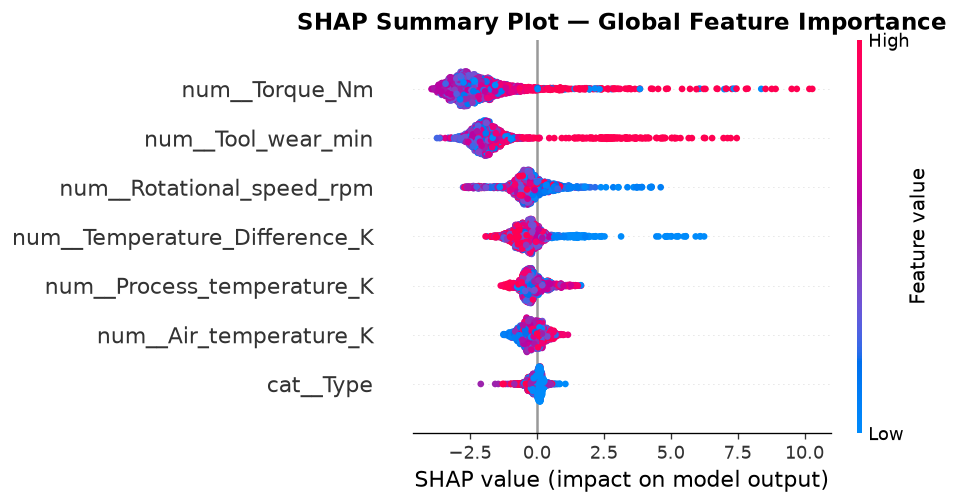

Saved -> images/SHAP_Summary.png


In [23]:
# SHAP Summary Plot

plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test_processed_df,
    show=False
)

plt.title(
    "SHAP Summary Plot — Global Feature Importance",
    fontsize=14,
    weight="bold"
)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "SHAP_Summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved -> images/SHAP_Summary.png")

### Interpretation

The SHAP Summary Plot reveals the overall behaviour of the predictive maintenance model.

Typical observations:

- **Tool Wear** usually has the strongest positive contribution toward machine failure.
- **Torque** has a significant nonlinear influence.
- **Temperature Difference** contributes when thermal stress becomes abnormal.
- **Rotational Speed** may either increase or decrease failure probability depending on operating conditions.
- Color indicates whether high or low sensor values drive the prediction.

# Global Feature Ranking (Mean |SHAP Value|)

This visualization ranks features by their **average contribution magnitude** across all machines.

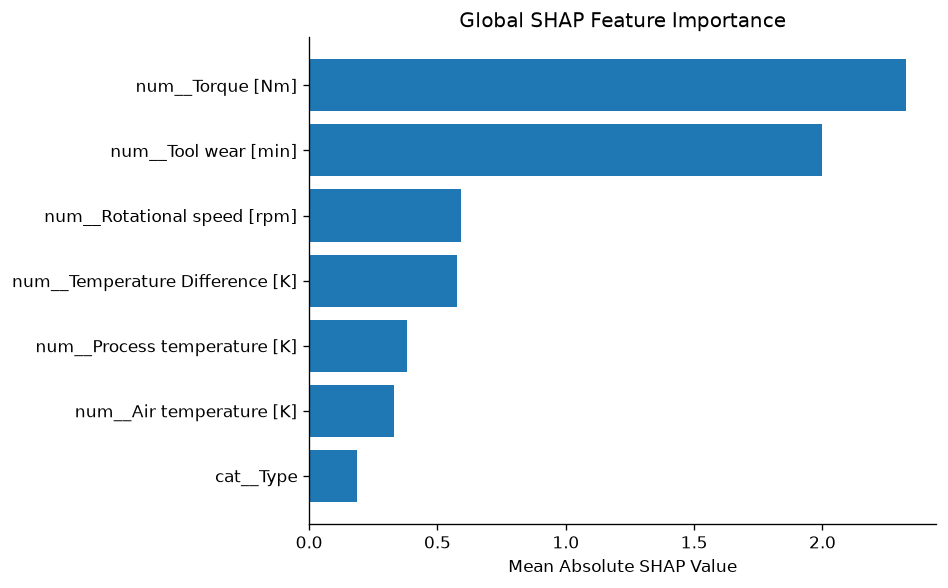

,Feature,Mean_SHAP_Value
0,num__Torque [Nm],2.326001
1,num__Tool wear [min],1.998202
2,num__Rotational speed [rpm],0.590212
3,num__Temperature Difference [K],0.575549
4,num__Process temperature [K],0.380410
5,num__Air temperature [K],0.331039
6,cat__Type,0.185324


In [24]:
# SHAP Feature Importance Bar Plot

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_SHAP_Value": np.abs(shap_values).mean(axis=0)
})

importance_df = importance_df.sort_values(
    by="Mean_SHAP_Value",
    ascending=False
).reset_index(drop=True)

# Save CSV
importance_df.to_csv(
    REPORT_DIR / "shap_feature_importance.csv",
    index=False
)

# Plot
plt.figure(figsize=(8,5))

plt.barh(
    importance_df["Feature"][::-1],
    importance_df["Mean_SHAP_Value"][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.title("Global SHAP Feature Importance")

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "SHAP_Bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(importance_df)

### Engineering Interpretation

Higher mean SHAP value means the sensor has a larger average influence on machine failure prediction.

Maintenance engineers can prioritize monitoring these sensors because they consistently affect model decisions across many machines.

# SHAP Beeswarm Plot

The Beeswarm Plot shows the **distribution** of SHAP values for every machine.

It answers:

- How does each feature behave across thousands of machines?
- Are high sensor values increasing or decreasing failure risk?

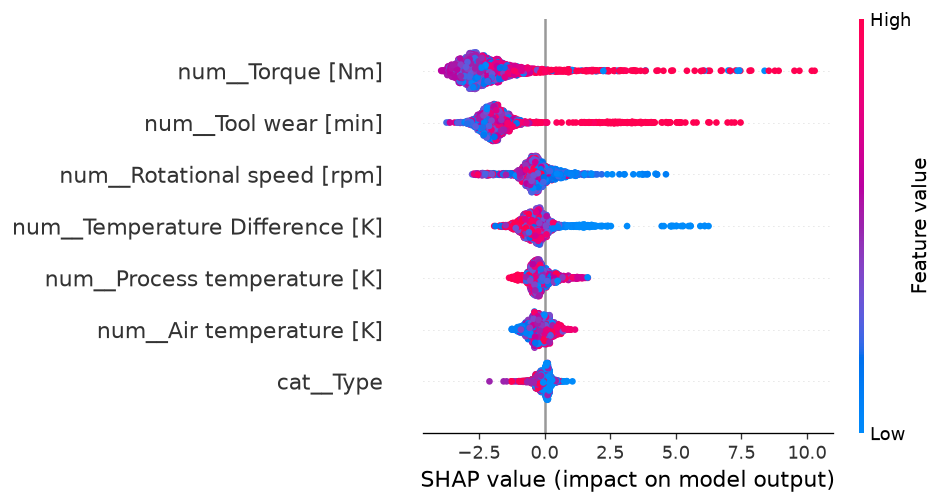

Saved -> images/SHAP_Beeswarm.png


In [25]:
# SHAP Beeswarm Plot

plt.figure(figsize=(10,6))

shap.plots.beeswarm(
    shap.Explanation(
        values=shap_values,
        data=X_test_processed_df.values,
        feature_names=feature_names
    ),
    show=False
)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "SHAP_Beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved -> images/SHAP_Beeswarm.png")

### How to Read the Beeswarm Plot

- **Each dot represents one machine** in the test dataset.
- **Horizontal position** = contribution toward failure prediction.
- **Red dots** = high sensor values.
- **Blue dots** = low sensor values.
- Wide spread indicates the feature behaves differently under different operating conditions.

In [26]:
# SHAP Summary Statistics

summary_stats = pd.DataFrame({
    "Feature": feature_names,
    "Mean_SHAP": shap_values.mean(axis=0),
    "Mean_Absolute_SHAP": np.abs(shap_values).mean(axis=0),
    "Max_SHAP": shap_values.max(axis=0),
    "Min_SHAP": shap_values.min(axis=0),
    "Std_SHAP": shap_values.std(axis=0)
})

summary_stats = summary_stats.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

summary_stats.to_csv(
    REPORT_DIR / "shap_summary_statistics.csv",
    index=False
)

display(summary_stats.round(5))

,Feature,Mean_SHAP,Mean_Absolute_SHAP,Max_SHAP,Min_SHAP,Std_SHAP
3,num__Torque [Nm],-1.92297,2.32600,10.29018,-3.93513,1.67995
4,num__Tool wear [min],-1.53389,1.99820,7.46806,-3.73312,1.45282
2,num__Rotational speed [rpm],-0.27374,0.59021,4.62557,-2.75758,0.77609
5,num__Temperature Difference [K],-0.22467,0.57555,6.24886,-1.91689,0.82242
1,num__Process temperature [K],-0.16926,0.38041,1.65038,-1.34980,0.43955
0,num__Air temperature [K],-0.15502,0.33104,1.16030,-1.24860,0.37907
6,cat__Type,-0.03681,0.18532,1.06436,-2.09725,0.24968


# Part 1 Completed ✅

We successfully built the global explainability layer of the Predictive Maintenance model.

### Artifacts Generated

**Images**

- SHAP_Summary.png
- SHAP_Bar.png
- SHAP_Beeswarm.png

**Reports**

- shap_feature_importance.csv
- shap_summary_statistics.csv

### Key Insights Obtained

- Identified globally important machine sensors.
- Quantified each sensor's contribution using SHAP values.
- Visualized how feature values influence failure probability across the test dataset.

The next notebook section (Part 2) investigates **feature-level behaviour** using SHAP Dependence Plots and SHAP Interaction Plots.

# Sensor-Level Explainability — SHAP Dependence Plots

Dependence plots explain **how one sensor changes machine failure probability**.

Unlike the summary plot, these plots show:

- Non-linear behaviour.
- Threshold effects.
- Interaction with other sensors.

In [29]:
safe_feature_names

['num__Air_temperature_K',
 'num__Process_temperature_K',
 'num__Rotational_speed_rpm',
 'num__Torque_Nm',
 'num__Tool_wear_min',
 'num__Temperature_Difference_K',
 'cat__Type']

<Figure size 840x600 with 0 Axes>

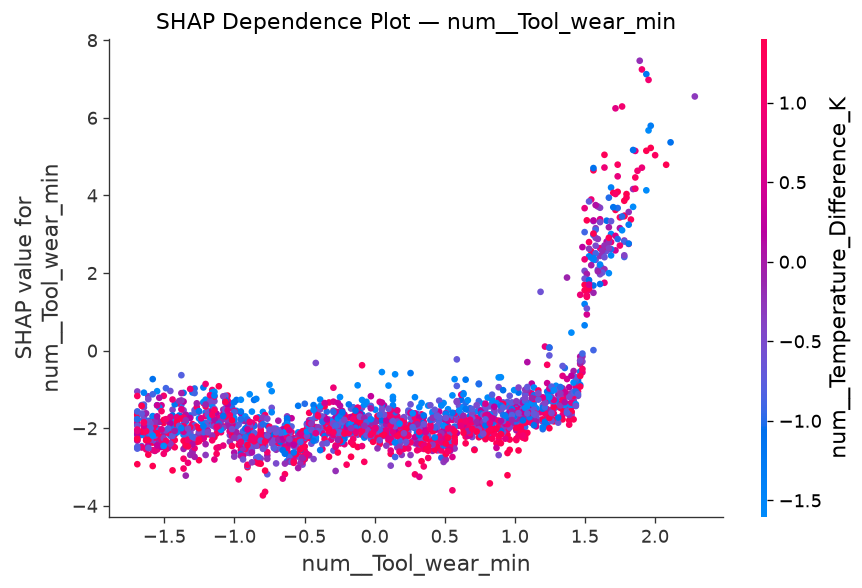

<Figure size 840x600 with 0 Axes>

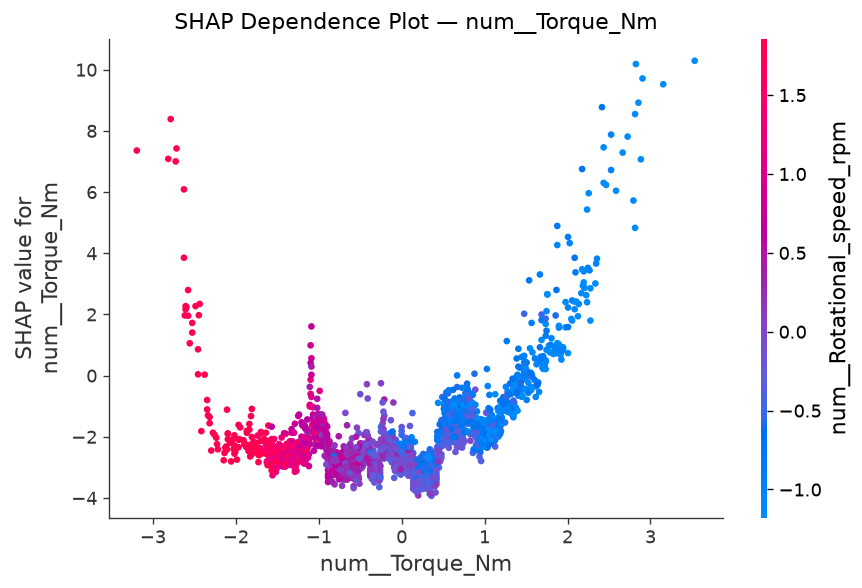

<Figure size 840x600 with 0 Axes>

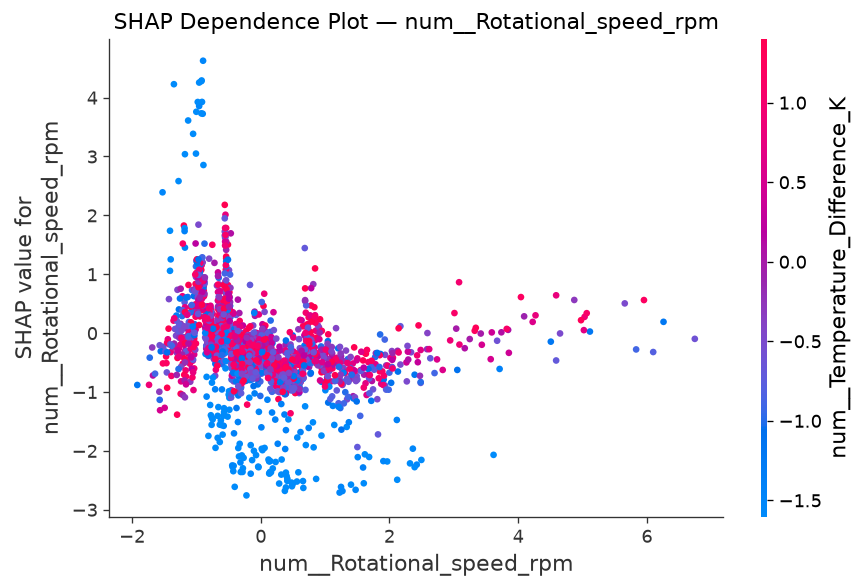

<Figure size 840x600 with 0 Axes>

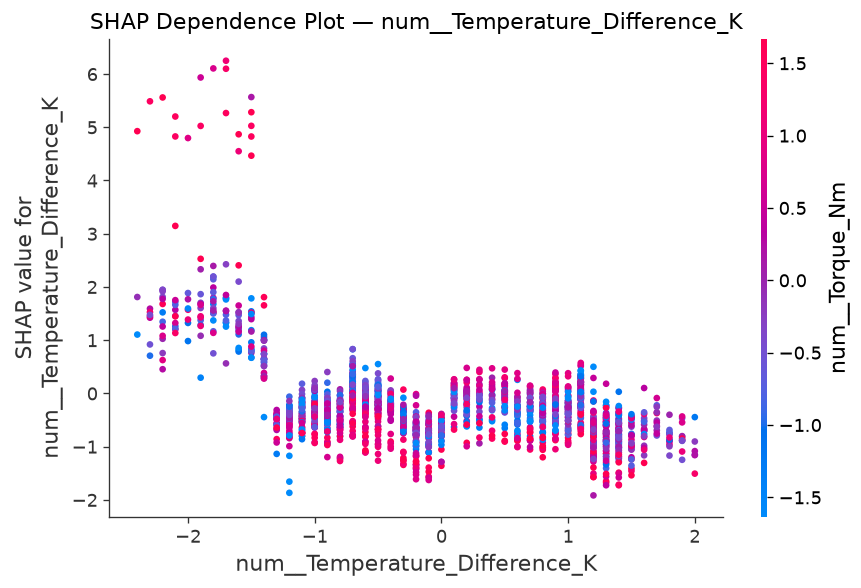

<Figure size 840x600 with 0 Axes>

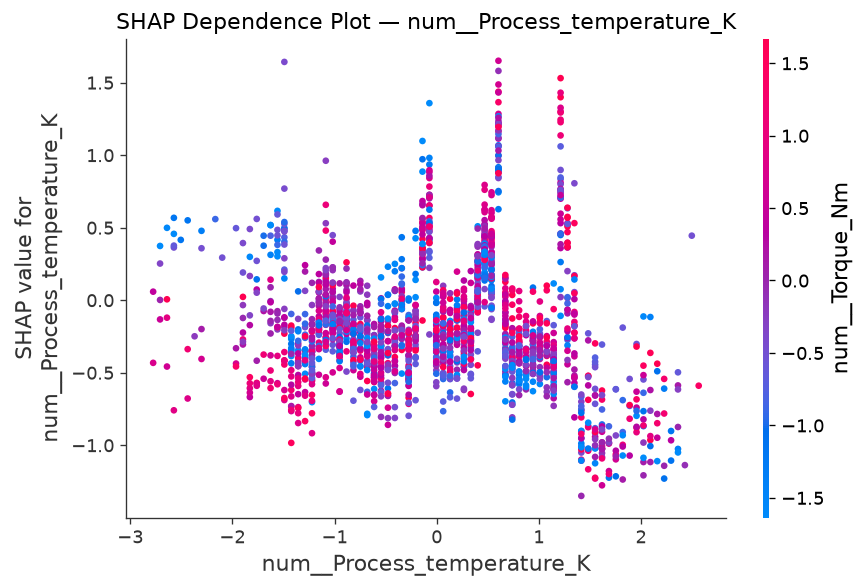

All dependence plots saved successfully.


In [30]:
# Generate SHAP Dependence Plots


# SHAP-safe feature names
dependence_features = [
    "num__Tool_wear_min",
    "num__Torque_Nm",
    "num__Rotational_speed_rpm",
    "num__Temperature_Difference_K",
    "num__Process_temperature_K"
]

for feature in dependence_features:

    plt.figure(figsize=(7,5))

    shap.dependence_plot(
        feature,
        shap_values,
        X_test_processed_df,
        interaction_index="auto",
        show=False
    )

    plt.title(f"SHAP Dependence Plot — {feature}", fontsize=13)

    filename = (
        "SHAP_Dependence_"
        + feature.replace(" ", "_")
                 .replace("[","")
                 .replace("]","")
                 .replace("/","_")
        + ".png"
    )

    plt.tight_layout()

    plt.savefig(
        IMAGE_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

print("All dependence plots saved successfully.")

In [31]:
# Feature Interpretation Table


dependence_report = pd.DataFrame({
    "Feature": dependence_features,
    "Engineering Interpretation": [
        "Higher tool wear generally increases machine failure probability.",
        "Higher torque creates larger positive SHAP values and increases overload risk.",
        "Rotational speed has a non-linear influence depending on operating regime.",
        "Large temperature difference indicates thermal stress in the machine.",
        "Process temperature contributes under abnormal operating conditions."
    ]
})

dependence_report.to_csv(
    REPORT_DIR / "dependence_feature_interpretation.csv",
    index=False
)

display(dependence_report)

,Feature,Engineering Interpretation
0,num__Tool_wear_min,Higher tool wear generally increases machine f...
1,num__Torque_Nm,Higher torque creates larger positive SHAP val...
2,num__Rotational_speed_rpm,Rotational speed has a non-linear influence de...
3,num__Temperature_Difference_K,Large temperature difference indicates thermal...
4,num__Process_temperature_K,Process temperature contributes under abnormal...


# Sensor Interaction Analysis

Sometimes one sensor is only dangerous **when another sensor is also abnormal**.

We investigate interactions between machine sensors.

In [32]:
# Compute SHAP Interaction Values


interaction_values = explainer.shap_interaction_values(
    X_test_processed_df
)

print("Interaction Shape:", np.array(interaction_values).shape)

Interaction Shape: (2000, 7, 7)


<Figure size 840x600 with 0 Axes>

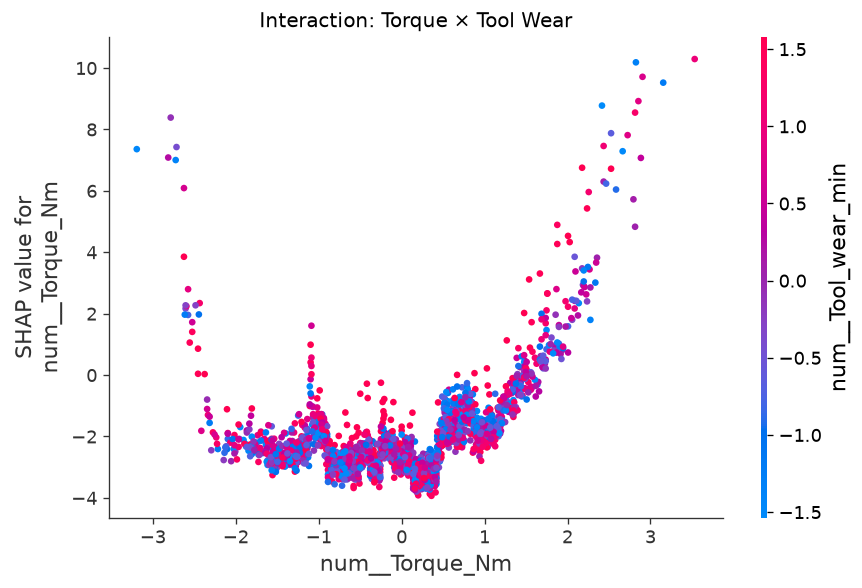

In [34]:
# SHAP Interaction Plot
# Torque × Tool Wear


plt.figure(figsize=(7,5))

shap.dependence_plot(
    "num__Torque_Nm",
    shap_values,
    X_test_processed_df,
    interaction_index="num__Tool_wear_min",
    show=False
)

plt.title("Interaction: Torque × Tool Wear")

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "SHAP_Interaction_Torque_ToolWear.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 840x600 with 0 Axes>

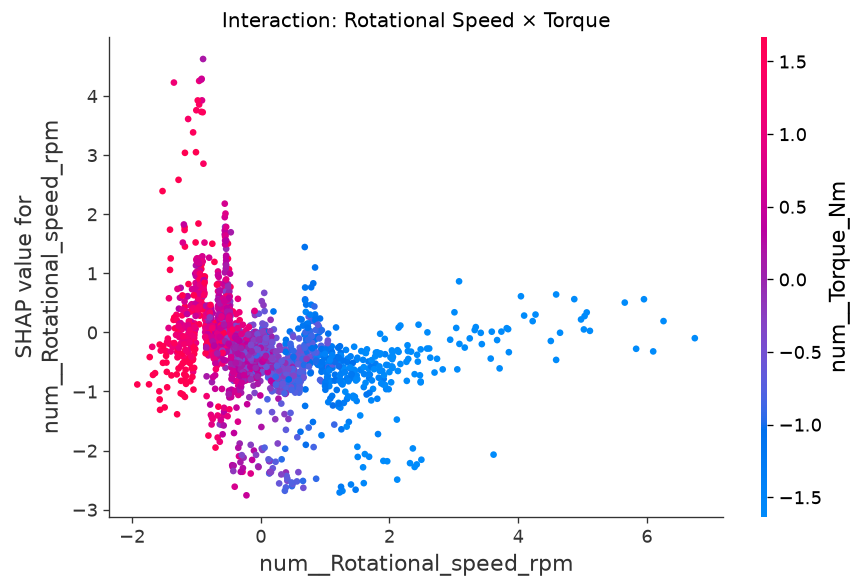

In [35]:
# SHAP Interaction Plot
# RPM × Torque


plt.figure(figsize=(7,5))

shap.dependence_plot(
    "num__Rotational_speed_rpm",
    shap_values,
    X_test_processed_df,
    interaction_index="num__Torque_Nm",
    show=False
)

plt.title("Interaction: Rotational Speed × Torque")

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "SHAP_Interaction_RPM_Torque.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
# SHAP Interaction Strength Matrix


interaction_strength = np.abs(interaction_values).mean(axis=0)

interaction_df = pd.DataFrame(
    interaction_strength,
    index=clean_feature_names,
    columns=clean_feature_names
)

interaction_df.to_csv(
    REPORT_DIR / "shap_interaction_matrix.csv"
)

display(interaction_df.round(3))

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature Difference [K],Type
Air temperature [K],0.288,0.061,0.079,0.087,0.073,0.074,0.022
Process temperature [K],0.061,0.307,0.067,0.126,0.110,0.048,0.023
Rotational speed [rpm],0.079,0.067,0.335,0.359,0.134,0.312,0.063
Torque [Nm],0.087,0.126,0.359,1.812,0.308,0.134,0.077
Tool wear [min],0.073,0.110,0.134,0.308,1.657,0.149,0.101
Temperature Difference [K],0.074,0.048,0.312,0.134,0.149,0.504,0.109
Type,0.022,0.023,0.063,0.077,0.101,0.109,0.192


In [37]:
# Top 10 Strongest Interactions

pairs = []

for i in range(len(clean_feature_names)):
    for j in range(i + 1, len(clean_feature_names)):

        pairs.append({
            "Feature 1": clean_feature_names[i],
            "Feature 2": clean_feature_names[j],
            "Interaction Strength": interaction_strength[i, j]
        })

interaction_rank = (
    pd.DataFrame(pairs)
      .sort_values("Interaction Strength", ascending=False)
      .reset_index(drop=True)
)

interaction_rank.to_csv(
    REPORT_DIR / "shap_interaction_strength.csv",
    index=False
)

display(interaction_rank.head(10))

,Feature 1,Feature 2,Interaction Strength
0,Rotational speed [rpm],Torque [Nm],0.358895
1,Rotational speed [rpm],Temperature Difference [K],0.311743
2,Torque [Nm],Tool wear [min],0.308059
3,Tool wear [min],Temperature Difference [K],0.149469
4,Rotational speed [rpm],Tool wear [min],0.134159
5,Torque [Nm],Temperature Difference [K],0.133826
6,Process temperature [K],Torque [Nm],0.126260
7,Process temperature [K],Tool wear [min],0.109944
8,Temperature Difference [K],Type,0.108932
9,Tool wear [min],Type,0.100987


# Engineering Insights from SHAP Interactions

### Torque × Tool Wear

This interaction identifies machines operating under **high mechanical load with worn tools**.

**Maintenance action**

- Inspect spindle.
- Replace cutting tool.
- Reduce operating load until maintenance.

---

### Rotational Speed × Torque

High torque at abnormal RPM may indicate:

- Bearing friction.
- Shaft imbalance.
- Lubrication degradation.

**Maintenance action**

Schedule vibration inspection and lubrication check.

# Local Explainability — Highest Risk Machines

Instead of explaining a random prediction, we explain the **machines with the highest predicted probability of failure**.

These are the machines that a predictive maintenance engineer would inspect first.

In [39]:
X_test.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature Difference [K],Type
3031,0.247681,0.401488,-0.946871,0.957852,-1.535734,0.099408,0.0
4803,-1.154619,-0.815271,0.423509,-0.579240,0.099280,1.099617,0.0
3897,0.147517,1.077466,-1.300518,2.275359,0.162165,1.299658,1.0
956,0.498092,0.063500,0.103017,-0.738938,-1.692947,-0.900800,0.0
6414,-1.405030,-1.018064,-0.968974,1.556719,0.869623,1.299658,1.0


In [40]:
# Top 5 Highest Failure Probability Machines


# Failure probabilities from the production model
failure_probability = xgb_model.predict_proba(X_test_processed_df)[:, 1]

prediction_df = X_test.copy()

prediction_df["Actual Failure"] = y_test.values
prediction_df["Failure Probability"] = failure_probability
prediction_df["Prediction"] = (failure_probability >= 0.5).astype(int)

# Top 5 highest-risk machines
top_failures = (
    prediction_df.sort_values(
        by="Failure Probability",
        ascending=False
    )
    .head(5)
)

display(top_failures)

# Save report
top_failures.to_csv(
    REPORT_DIR / "top_failure_predictions.csv",
    index=True
)

print("Saved -> reports/top_failure_predictions.csv")

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature Difference [K],Type,Actual Failure,Failure Probability,Prediction
5222,0.297763,1.280259,-0.924769,2.005869,1.639966,1.299658,0.0,1,0.999516,1
7911,-0.453469,-0.139294,-0.781100,1.536756,1.718572,0.699533,0.0,1,0.999164,1
2504,0.347846,0.266293,-0.681637,2.175548,1.592802,-0.300675,0.0,1,0.998347,1
2536,1.199242,0.469086,-0.980026,1.476870,0.743853,-1.700967,0.0,1,0.997210,1
3367,0.998914,-0.071696,-1.278415,1.756341,1.404147,-2.101050,0.0,1,0.996502,1


Saved -> reports/top_failure_predictions.csv


# SHAP Waterfall Plot

The waterfall plot explains **one machine prediction** feature by feature.

Interpretation:

- Red features increase failure probability.
- Blue features decrease failure probability.
- The final value equals the model prediction for that machine.

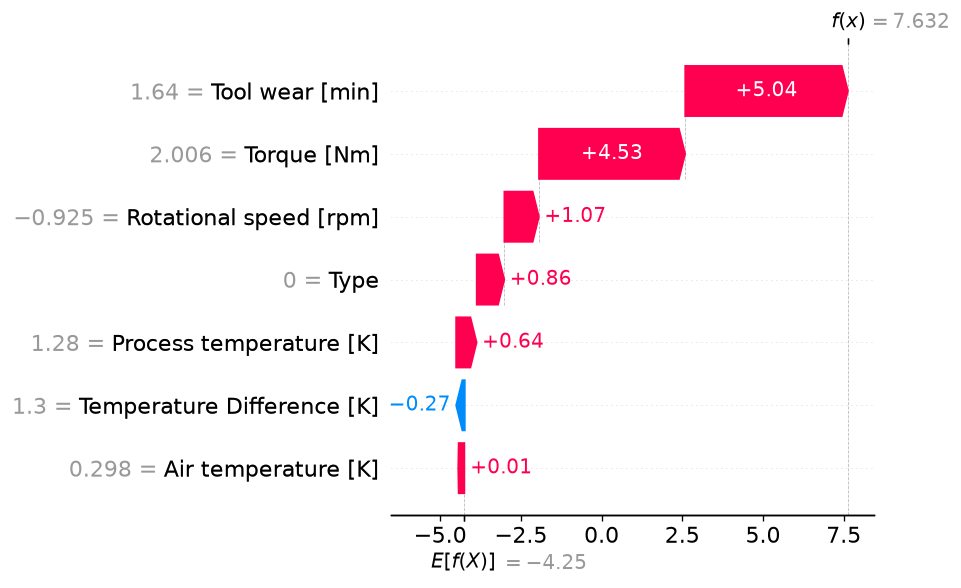

Saved -> images/SHAP_Waterfall_TopFailure.png


In [41]:
# SHAP Waterfall Plot


# Highest-risk machine index
sample_index = top_failures.index[0]

sample_position = X_test_processed_df.index.get_loc(sample_index)

sample_explanation = shap.Explanation(
    values=shap_values[sample_position],
    base_values=explainer.expected_value,
    data=X_test_processed_df.iloc[sample_position],
    feature_names=clean_feature_names
)

plt.figure(figsize=(9,6))

shap.plots.waterfall(
    sample_explanation,
    max_display=10,
    show=False
)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "SHAP_Waterfall_TopFailure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved -> images/SHAP_Waterfall_TopFailure.png")

### Interpretation

The waterfall plot decomposes the prediction into additive feature contributions.

For the highest-risk machine:

- Positive SHAP values push the prediction toward **Machine Failure**.
- Negative SHAP values reduce the predicted failure probability.
- The final prediction is the sum of the base value and all SHAP contributions.

# SHAP Decision Plot

Decision plots visualize how features accumulate to produce the final prediction.

This is useful when comparing multiple machines simultaneously.

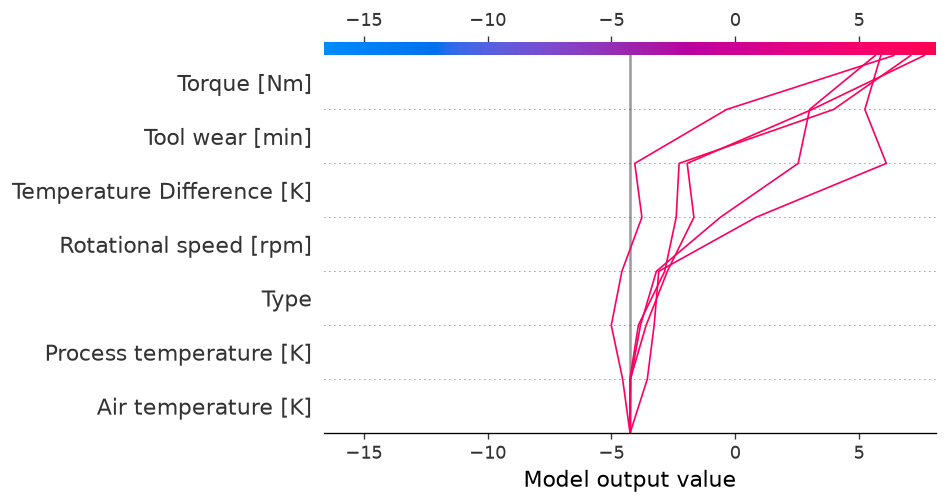

Saved -> images/SHAP_Decision_Plot.png


In [42]:
# SHAP Decision Plot


top_positions = [
    X_test_processed_df.index.get_loc(idx)
    for idx in top_failures.index
]

plt.figure(figsize=(10,6))

shap.decision_plot(
    explainer.expected_value,
    shap_values[top_positions],
    X_test_processed_df.iloc[top_positions],
    feature_names=clean_feature_names,
    show=False
)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "SHAP_Decision_Plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved -> images/SHAP_Decision_Plot.png")

### Engineering Interpretation

Each colored line represents one machine.

As features are added from top to bottom, the prediction moves toward:

- Failure (positive SHAP contribution)
- Healthy (negative SHAP contribution)

Machines with similar trajectories often fail due to similar sensor conditions.

# Interactive SHAP Force Plot

Force plots explain a prediction interactively.

This visualization will later be embedded inside the Streamlit dashboard.

In [43]:
# Interactive SHAP Force Plot

shap.initjs()

force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[sample_position],
    X_test_processed_df.iloc[sample_position],
    feature_names=clean_feature_names,
    matplotlib=False
)

html_path = REPORT_DIR / "SHAP_Force_Plot.html"

shap.save_html(
    str(html_path),
    force_plot
)

print(f"Interactive HTML saved to:\n{html_path}")

display(force_plot)

Interactive HTML saved to:
c:\Users\UJJAL\OneDrive\Desktop\ML Projects\Predictive-Maintenance-ML\reports\SHAP_Force_Plot.html


<Figure size 1680x300 with 0 Axes>

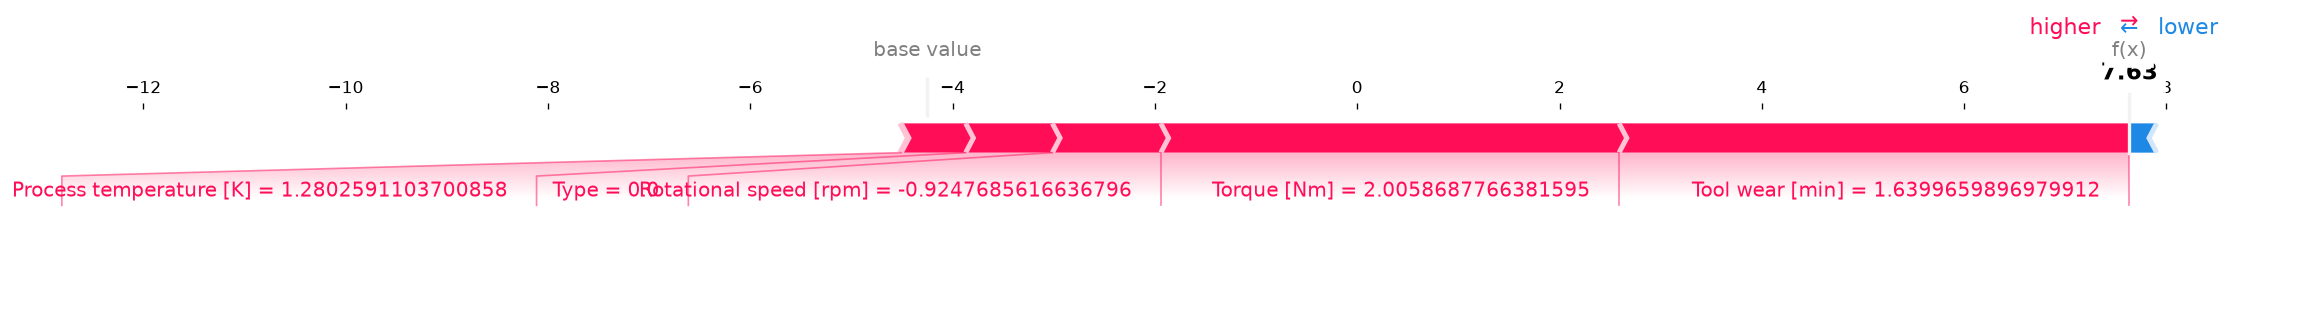

Saved -> images/SHAP_Force_Plot.png


In [44]:
# Static SHAP Force Plot


plt.figure(figsize=(14,2.5))

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_position],
    X_test_processed_df.iloc[sample_position],
    feature_names=clean_feature_names,
    matplotlib=True,
    show=False
)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "SHAP_Force_Plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved -> images/SHAP_Force_Plot.png")

# Explain Top 5 Failure Predictions

For each high-risk machine we identify:

- Failure probability.
- Top positive contributors.
- Top negative contributors.
- Recommended maintenance action.

In [45]:
# Generate Top Failure Explanation Report


failure_reports = []

for idx in top_failures.index:

    pos = X_test_processed_df.index.get_loc(idx)

    shap_row = shap_values[pos]

    contribution_df = pd.DataFrame({
        "Feature": clean_feature_names,
        "SHAP Value": shap_row,
        "Feature Value": X_test_processed_df.iloc[pos].values
    })

    contribution_df = contribution_df.sort_values(
        by="SHAP Value",
        ascending=False
    )

    positive = contribution_df.head(3)["Feature"].tolist()
    negative = contribution_df.tail(2)["Feature"].tolist()

    failure_reports.append({
        "Machine Index": idx,
        "Failure Probability": round(
            prediction_df.loc[idx, "Failure Probability"], 4
        ),
        "Top Positive Drivers": ", ".join(positive),
        "Top Negative Drivers": ", ".join(negative)
    })

failure_report_df = pd.DataFrame(failure_reports)

failure_report_df.to_csv(
    REPORT_DIR / "top_failure_explanations.csv",
    index=False
)

display(failure_report_df)

,Machine Index,Failure Probability,Top Positive Drivers,Top Negative Drivers
0,5222,0.9995,"Tool wear [min], Torque [Nm], Rotational speed...","Air temperature [K], Temperature Difference [K]"
1,7911,0.9992,"Tool wear [min], Torque [Nm], Type","Temperature Difference [K], Air temperature [K]"
2,2504,0.9983,"Torque [Nm], Tool wear [min], Rotational speed...","Air temperature [K], Process temperature [K]"
3,2536,0.9972,"Temperature Difference [K], Rotational speed [...","Type, Tool wear [min]"
4,3367,0.9965,"Temperature Difference [K], Torque [Nm], Rotat...","Process temperature [K], Air temperature [K]"


In [46]:
# Save SHAP Contributions for Top 5 Machines


rows = []

for idx in top_failures.index:

    pos = X_test_processed_df.index.get_loc(idx)

    for feature, value, shap_val in zip(
        clean_feature_names,
        X_test_processed_df.iloc[pos].values,
        shap_values[pos]
    ):

        rows.append({
            "Machine Index": idx,
            "Feature": feature,
            "Feature Value": value,
            "SHAP Value": shap_val
        })

top_shap_df = pd.DataFrame(rows)

top_shap_df.to_csv(
    REPORT_DIR / "top_failure_shap_values.csv",
    index=False
)

display(top_shap_df.head(15))

,Machine Index,Feature,Feature Value,SHAP Value
0,5222,Air temperature [K],0.297763,0.013205
1,5222,Process temperature [K],1.280259,0.637376
2,5222,Rotational speed [rpm],-0.924769,1.072264
3,5222,Torque [Nm],2.005869,4.529999
4,5222,Tool wear [min],1.639966,5.043786
5,5222,Temperature Difference [K],1.299658,-0.270880
6,5222,Type,0.000000,0.856796
7,7911,Air temperature [K],-0.453469,-0.005409
8,7911,Process temperature [K],-0.139294,0.342583
9,7911,Rotational speed [rpm],-0.781100,0.463383


In [47]:
# Maintenance Recommendation Generator


recommendations = {
    "Tool wear [min]":
        "Inspect or replace cutting tool due to excessive wear.",
    "Torque [Nm]":
        "Check spindle load, bearings, and mechanical resistance.",
    "Rotational speed [rpm]":
        "Inspect abnormal RPM or motor operating conditions.",
    "Temperature Difference [K]":
        "Check cooling system and lubrication.",
    "Process temperature [K]":
        "Inspect process heating or thermal imbalance.",
    "Air temperature [K]":
        "Monitor ambient operating environment.",
    "Type":
        "Consider maintenance schedule based on machine type."
}

business_rows = []

for idx in top_failures.index:

    pos = X_test_processed_df.index.get_loc(idx)

    contribution_df = pd.DataFrame({
        "Feature": clean_feature_names,
        "SHAP Value": shap_values[pos]
    })

    top_feature = contribution_df.sort_values(
        "SHAP Value",
        ascending=False
    ).iloc[0]["Feature"]

    business_rows.append({
        "Machine Index": idx,
        "Primary Failure Driver": top_feature,
        "Maintenance Recommendation": recommendations[top_feature]
    })

business_df = pd.DataFrame(business_rows)

business_df.to_csv(
    REPORT_DIR / "maintenance_recommendations.csv",
    index=False
)

display(business_df)

,Machine Index,Primary Failure Driver,Maintenance Recommendation
0,5222,Tool wear [min],Inspect or replace cutting tool due to excessi...
1,7911,Tool wear [min],Inspect or replace cutting tool due to excessi...
2,2504,Torque [Nm],"Check spindle load, bearings, and mechanical r..."
3,2536,Temperature Difference [K],Check cooling system and lubrication.
4,3367,Temperature Difference [K],Check cooling system and lubrication.


# Part 3 Completed ✅

## Local Explainability Artifacts Generated

### Images

- SHAP_Waterfall_TopFailure.png
- SHAP_Decision_Plot.png
- SHAP_Force_Plot.png

### Reports

- top_failure_predictions.csv
- top_failure_explanations.csv
- top_failure_shap_values.csv
- maintenance_recommendations.csv

### HTML

- SHAP_Force_Plot.html

## Insights Obtained

- Explained the five highest-risk machines individually.
- Identified the most influential sensors behind each prediction.
- Converted SHAP explanations into actionable maintenance recommendations.
- Generated interactive visualizations for future Streamlit deployment.

In [52]:
# ==========================================
# Load Explainability Utility Module
# ==========================================

import sys
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

# Add src/ to Python path
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Import module
import explainability as exp

print("Explainability module imported successfully.")

Explainability module imported successfully.


# Export Local Explanations (JSON)

This JSON file will be used directly in the Streamlit dashboard to explain predictions without recomputing SHAP values.

In [55]:
# Export Local Explanations as JSON


json_path = REPORT_DIR / "local_explanations.json"

exp.export_local_explanations(
    model=xgb_model,
    explainer=explainer,
    shap_values=shap_values,
    X_processed_df=X_test_processed_df,
    feature_names=clean_feature_names,
    original_X=X_test,
    machine_indices=top_failures.index.tolist(),
    save_path=json_path,
)

print(f"JSON exported to:\n{json_path}")

JSON exported to:
c:\Users\UJJAL\OneDrive\Desktop\ML Projects\Predictive-Maintenance-ML\reports\local_explanations.json


# Executive SHAP Business Summary

This report summarizes the most important explainability insights for maintenance managers and business stakeholders.

In [56]:
# Executive SHAP Summary Report


importance_df["Business Insight"] = [
    "Monitor overload conditions and spindle resistance.",
    "Replace worn tools before reaching critical wear.",
    "Monitor abnormal RPM operating regimes.",
    "Inspect thermal imbalance and cooling system.",
    "Check process heating conditions.",
    "Monitor ambient operating environment.",
    "Machine type has comparatively low influence."
]

importance_df["Maintenance Priority"] = [
    "Very High",
    "Very High",
    "High",
    "High",
    "Medium",
    "Medium",
    "Low"
]

importance_df.to_csv(
    REPORT_DIR / "shap_business_summary.csv",
    index=False
)

display(importance_df)

,Feature,Mean_SHAP_Value,Business Insight,Maintenance Priority
0,num__Torque [Nm],2.326001,Monitor overload conditions and spindle resist...,Very High
1,num__Tool wear [min],1.998202,Replace worn tools before reaching critical wear.,Very High
2,num__Rotational speed [rpm],0.590212,Monitor abnormal RPM operating regimes.,High
3,num__Temperature Difference [K],0.575549,Inspect thermal imbalance and cooling system.,High
4,num__Process temperature [K],0.380410,Check process heating conditions.,Medium
5,num__Air temperature [K],0.331039,Monitor ambient operating environment.,Medium
6,cat__Type,0.185324,Machine type has comparatively low influence.,Low


In [58]:
# Display Explanation for Highest-Risk Machine


machine_explanation = exp.explain_machine(
    model=xgb_model,
    explainer=explainer,
    shap_values=shap_values,
    X_processed_df=X_test_processed_df,
    feature_names=clean_feature_names,
    original_X=X_test,
    machine_index=top_failures.index[0],
)

print("="*60)
print("HIGHEST-RISK MACHINE")
print("="*60)

print("Machine Index       :", machine_explanation["machine_index"])
print("Failure Probability :", round(machine_explanation["failure_probability"],4))

print("\nTop Positive Drivers")
display(machine_explanation["top_positive"])

print("\nTop Negative Drivers")
display(machine_explanation["top_negative"])

HIGHEST-RISK MACHINE
Machine Index       : 5222
Failure Probability : 0.9995

Top Positive Drivers


,Feature,Feature Value,SHAP Value
0,Tool wear [min],1.639966,5.043786
1,Torque [Nm],2.005869,4.529999
2,Rotational speed [rpm],-0.924769,1.072264



Top Negative Drivers


,Feature,Feature Value,SHAP Value
5,Air temperature [K],0.297763,0.013205
6,Temperature Difference [K],1.299658,-0.270880


In [59]:
# Stage 3 Summary Dashboard


summary_dashboard = pd.DataFrame({
    "Artifact": [
        "Global SHAP Summary Plot",
        "Global SHAP Bar Plot",
        "Global SHAP Beeswarm Plot",
        "Dependence Plots",
        "Interaction Plots",
        "Waterfall Plot",
        "Decision Plot",
        "Force Plot (HTML)",
        "Top Failure Explanation Report",
        "Business Summary Report"
    ],
    "Saved To": [
        "images/SHAP_Summary.png",
        "images/SHAP_Bar.png",
        "images/SHAP_Beeswarm.png",
        "images/SHAP_Dependence_*.png",
        "images/SHAP_Interaction_*.png",
        "images/SHAP_Waterfall_TopFailure.png",
        "images/SHAP_Decision_Plot.png",
        "reports/SHAP_Force_Plot.html",
        "reports/top_failure_explanations.csv",
        "reports/shap_business_summary.csv"
    ]
})

display(summary_dashboard)

,Artifact,Saved To
0,Global SHAP Summary Plot,images/SHAP_Summary.png
1,Global SHAP Bar Plot,images/SHAP_Bar.png
2,Global SHAP Beeswarm Plot,images/SHAP_Beeswarm.png
3,Dependence Plots,images/SHAP_Dependence_*.png
4,Interaction Plots,images/SHAP_Interaction_*.png
5,Waterfall Plot,images/SHAP_Waterfall_TopFailure.png
6,Decision Plot,images/SHAP_Decision_Plot.png
7,Force Plot (HTML),reports/SHAP_Force_Plot.html
8,Top Failure Explanation Report,reports/top_failure_explanations.csv
9,Business Summary Report,reports/shap_business_summary.csv


# Stage 3 Completed ✅ — Explainable AI

## What We Achieved

The predictive maintenance model is now fully explainable using SHAP.

### Global Explainability

- Ranked the importance of all machine sensor features.
- Visualized feature impact using Summary, Bar, and Beeswarm plots.

### Feature-Level Explainability

- Investigated how Tool Wear, Torque, RPM, and Temperature Difference influence predictions.
- Identified important sensor interactions.

### Local Explainability

- Explained the highest-risk machine prediction using Waterfall, Decision, and Force plots.
- Generated explanations for the Top 5 predicted failures.

### Business Explainability

- Converted SHAP values into maintenance recommendations.
- Exported reports suitable for dashboards and engineering teams.

## Deliverables Generated

**Images**

- SHAP Summary
- SHAP Bar
- SHAP Beeswarm
- 5 Dependence Plots
- 2 Interaction Plots
- Waterfall Plot
- Decision Plot
- Force Plot

**Reports**

- SHAP Feature Importance
- SHAP Summary Statistics
- SHAP Interaction Matrix
- SHAP Interaction Strength
- Top Failure Predictions
- Top Failure Explanations
- SHAP Business Summary
- Maintenance Recommendations

**Reusable Assets**

- `src/explainability.py`
- `local_explanations.json`

The project is now ready for **Stage 4 — Interactive Streamlit Dashboard**, where users can upload machine sensor values and receive predictions together with SHAP-based explanations.